In [1]:
import pandas as pd

dataset = pd.read_csv('dataset_preprocessed.csv')

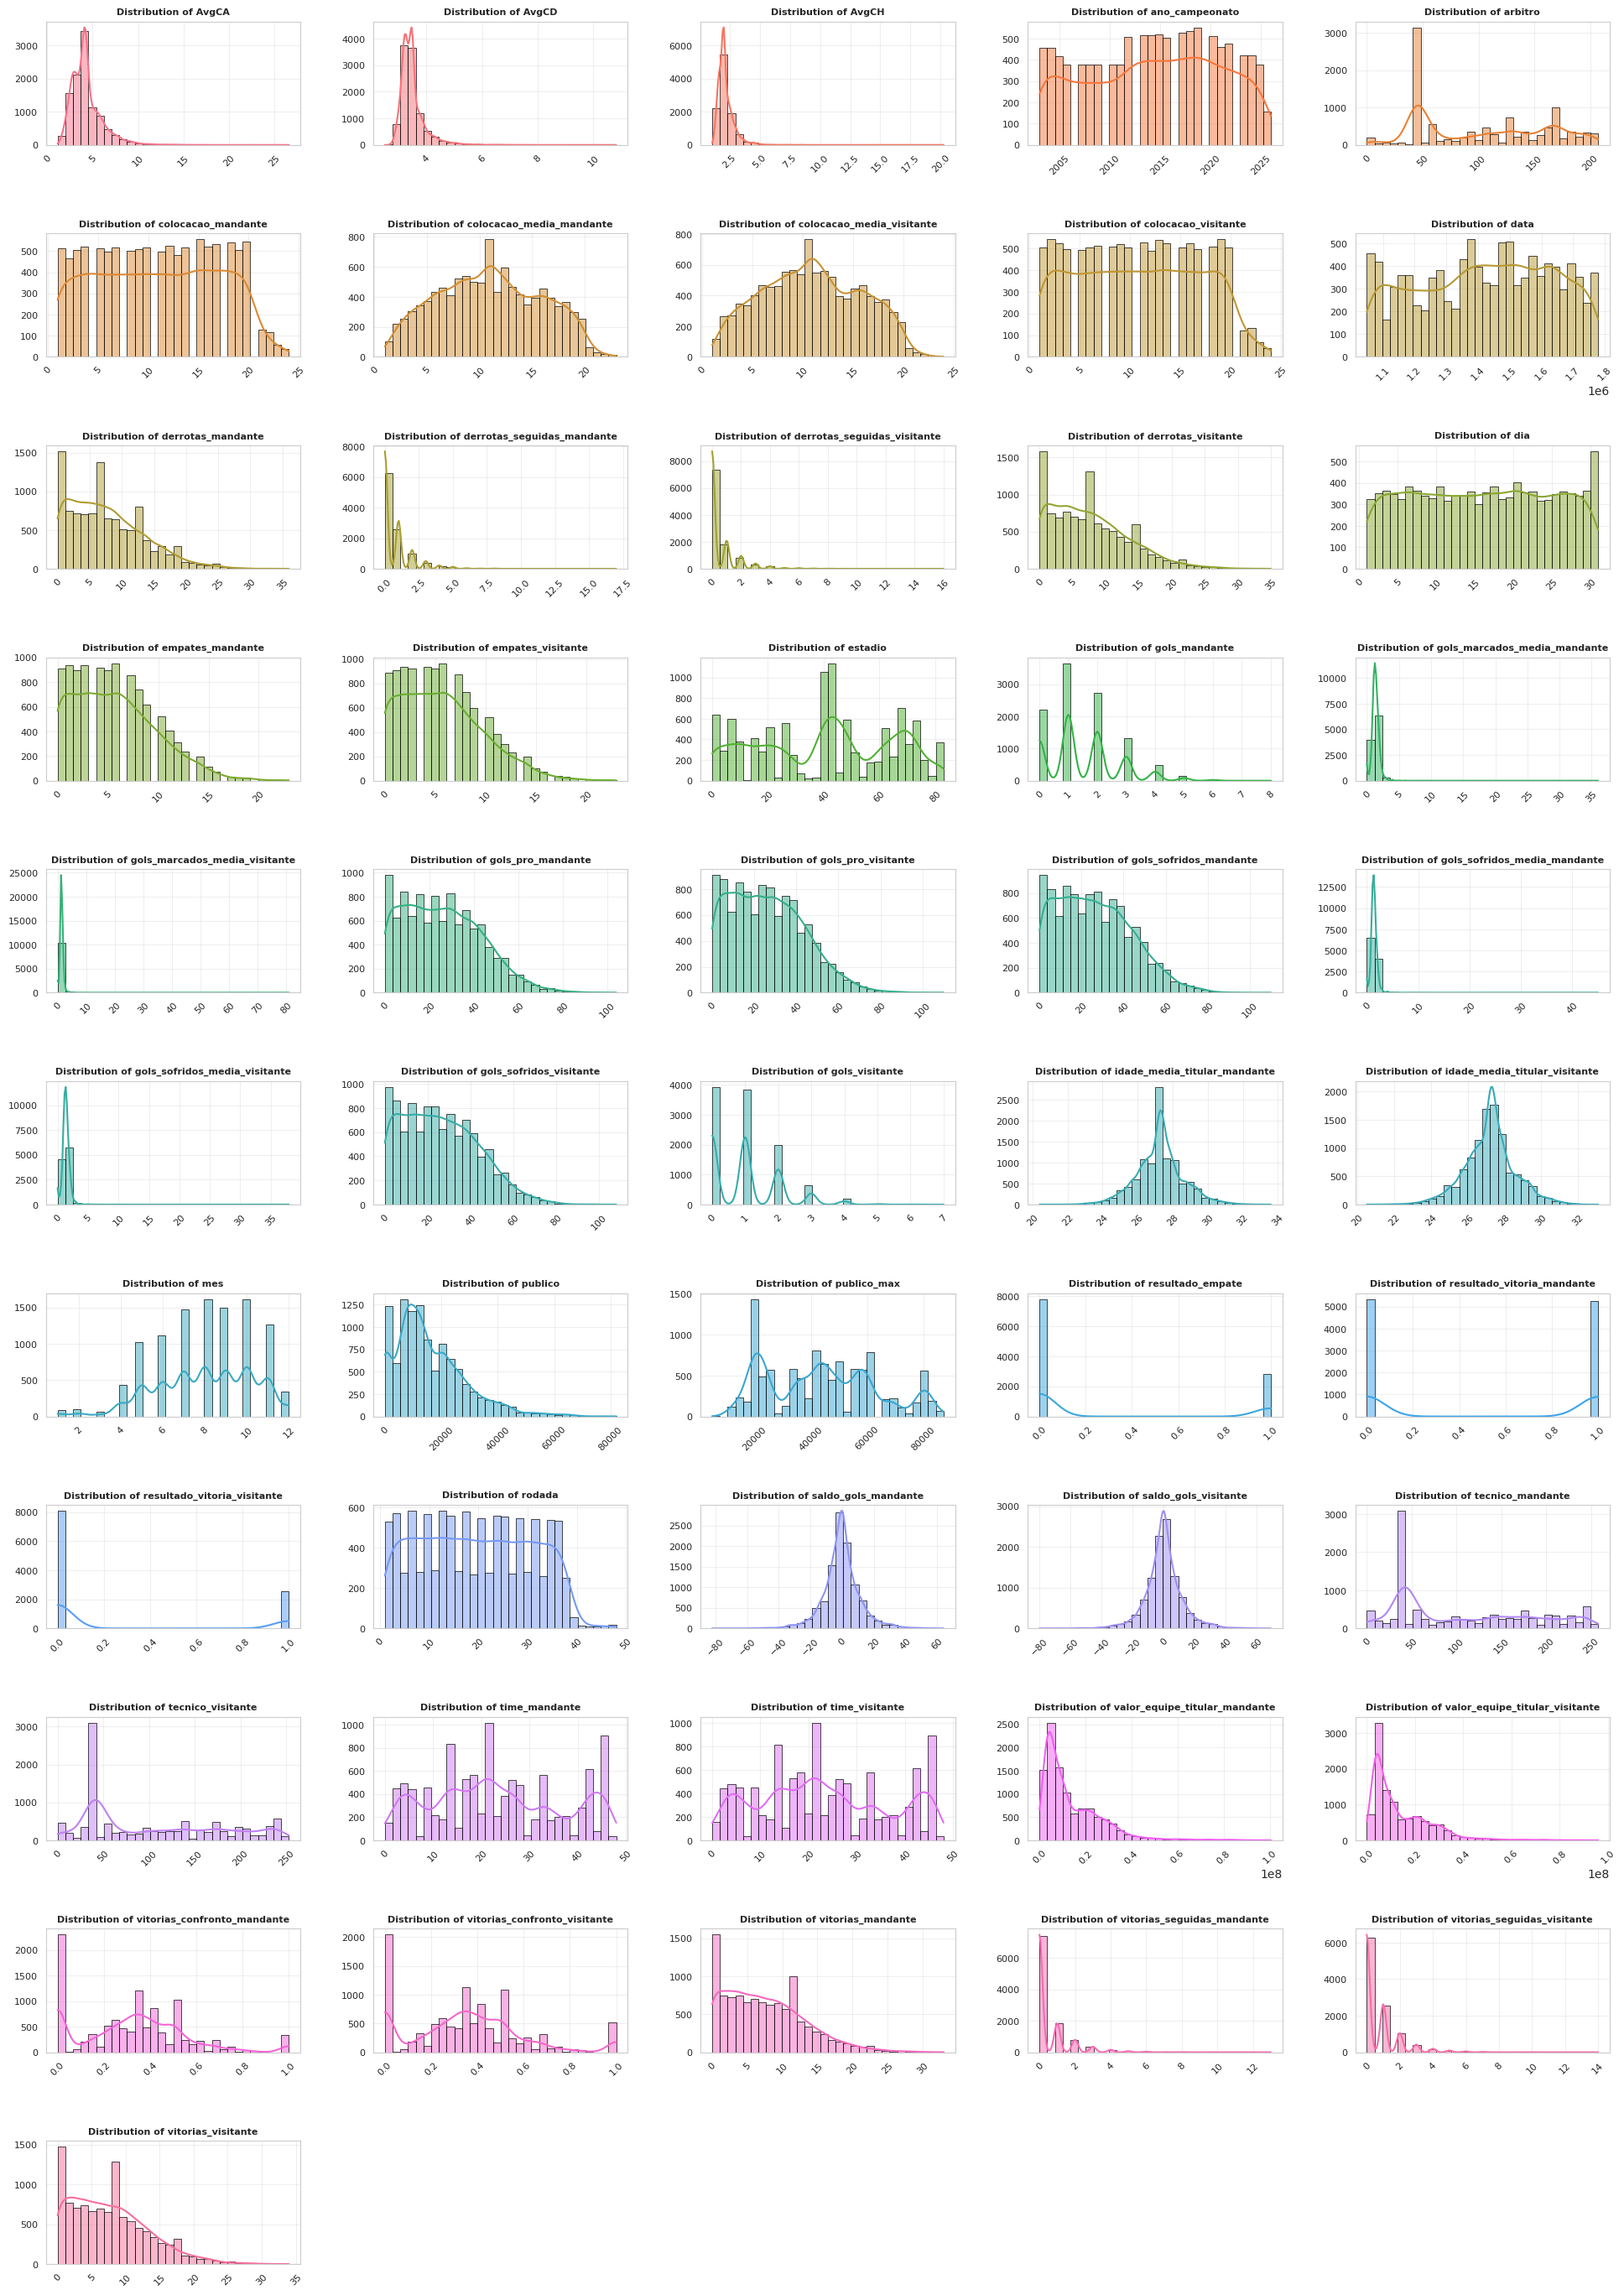

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_distributions(dataset):    
    # Set a visually appealing style for the plots
    sns.set_style('whitegrid')

    # Get the list of all columns in the dataset and sort them alphabetically
    columns = sorted(dataset.columns)
    num_columns = len(columns)

    # Define the grid size
    n_rows = 11
    n_cols = 5

    # Create the subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 28))

    # Flatten the axes array for easy iteration
    axes = axes.flatten()

    # Create a color palette
    palette = sns.color_palette("husl", num_columns)

    # Loop through the columns and plot a histogram for each
    for i, col in enumerate(columns):
        sns.histplot(dataset[col], kde=True, ax=axes[i], bins=30, color=palette[i], edgecolor='black', linewidth=0.5)
        axes[i].set_title(f'Distribution of {col}', fontsize=8, fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')
        axes[i].tick_params(axis='x', rotation=45, labelsize=8)
        axes[i].tick_params(axis='y', labelsize=8)
        axes[i].grid(alpha=0.3)

    # Hide any unused subplots
    for i in range(num_columns, len(axes)):
        axes[i].set_visible(False)

    # Adjust the layout to prevent titles and labels from overlapping
    plt.tight_layout(pad=3.0)

    # Display the plots
    plt.savefig('distributions.png', dpi=300)

plot_distributions(dataset)

In [3]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np

dist_normais_labels = ['saldo_gols_mandante', 'saldo_gols_visitante', 'idade_media_titular_mandante',
                       'idade_media_titular_visitante', 'colocacao_media_mandante', 'colocacao_media_visitante']

dist_cauda_longa_labels = ['publico', 'publico_max', 'valor_equipe_titular_mandante',
                           'valor_equipe_titular_visitante', 'AvgCH', 'AvgCD', 'AvgCA',
                           'gols_marcados_media_mandante', 'gols_marcados_media_visitante',
                           'gols_sofridos_media_mandante', 'gols_sofridos_media_visitante',
                           'vitorias_seguidas_mandante', 'vitorias_seguidas_visitante',
                           'derrotas_seguidas_mandante', 'derrotas_seguidas_visitante',
                           'gols_visitante', 'gols_mandante'
                           ]

dist_poisson_labels = ['vitorias_mandante', 'vitorias_visitante', 'empates_mandante', 
                       'empates_visitante', 'derrotas_mandante', 'derrotas_visitante', 
                       'gols_pro_mandante', 'gols_pro_visitante', 'gols_sofridos_mandante',
                       'gols_sofridos_visitante']

#dist_categoricas_ciclicas_labels = ['data', 'rodada', 'time_mandante', 'time_visitante',
#                                    'colocacao_mandante', 'colocacao_visitante', 'dia', 'mes',
#                                    'estadio', 'arbitro', 'tecnico_mandante', 'tecnico_visitante']

dist_categoricas_ciclicas_labels = ['data', 'rodada', 'colocacao_mandante', 'colocacao_visitante', 'dia', 'mes']

# Initialize scalers
standard_scaler = StandardScaler()
min_max_scaler = MinMaxScaler()

# Apply StandardScaler to normally distributed columns
for col in dist_normais_labels:
    if col in dataset.columns:
        dataset[col] = standard_scaler.fit_transform(dataset[[col]])

# Apply log transformation and then MinMaxScaler to long-tail distributed columns
for col in dist_cauda_longa_labels:
    if col in dataset.columns:
        dataset[col] = np.log1p(dataset[col])
        dataset[col] = min_max_scaler.fit_transform(dataset[[col]])

# Combine Poisson and cyclical categorical labels
dist_minmax_labels = dist_poisson_labels + dist_categoricas_ciclicas_labels

# Apply MinMaxScaler to the combined list of columns
for col in dist_minmax_labels:
    if col in dataset.columns:
        dataset[col] = min_max_scaler.fit_transform(dataset[[col]])

print("Scaling and transformations applied successfully.")
dataset.head()

Scaling and transformations applied successfully.


,ano_campeonato,data,rodada,estadio,arbitro,publico,publico_max,time_mandante,time_visitante,tecnico_mandante,...,gols_marcados_media_mandante,gols_marcados_media_visitante,vitorias_confronto_mandante,vitorias_confronto_visitante,vitorias_seguidas_mandante,vitorias_seguidas_visitante,colocacao_media_mandante,colocacao_media_visitante,derrotas_seguidas_mandante,derrotas_seguidas_visitante
0,2003,0.000000,0.0,8,45,0.835994,0.745767,5,26,42,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00705,-0.000294,0.0,0.0
1,2003,0.000000,0.0,22,45,0.808763,0.658530,27,46,42,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00705,-0.000294,0.0,0.0
2,2003,0.000118,0.0,81,45,0.908125,0.807146,13,4,42,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00705,-0.000294,0.0,0.0
3,2003,0.000118,0.0,42,45,0.826973,0.503914,15,22,42,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00705,-0.000294,0.0,0.0
4,2003,0.000118,0.0,39,45,0.883469,0.857007,16,44,42,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00705,-0.000294,0.0,0.0


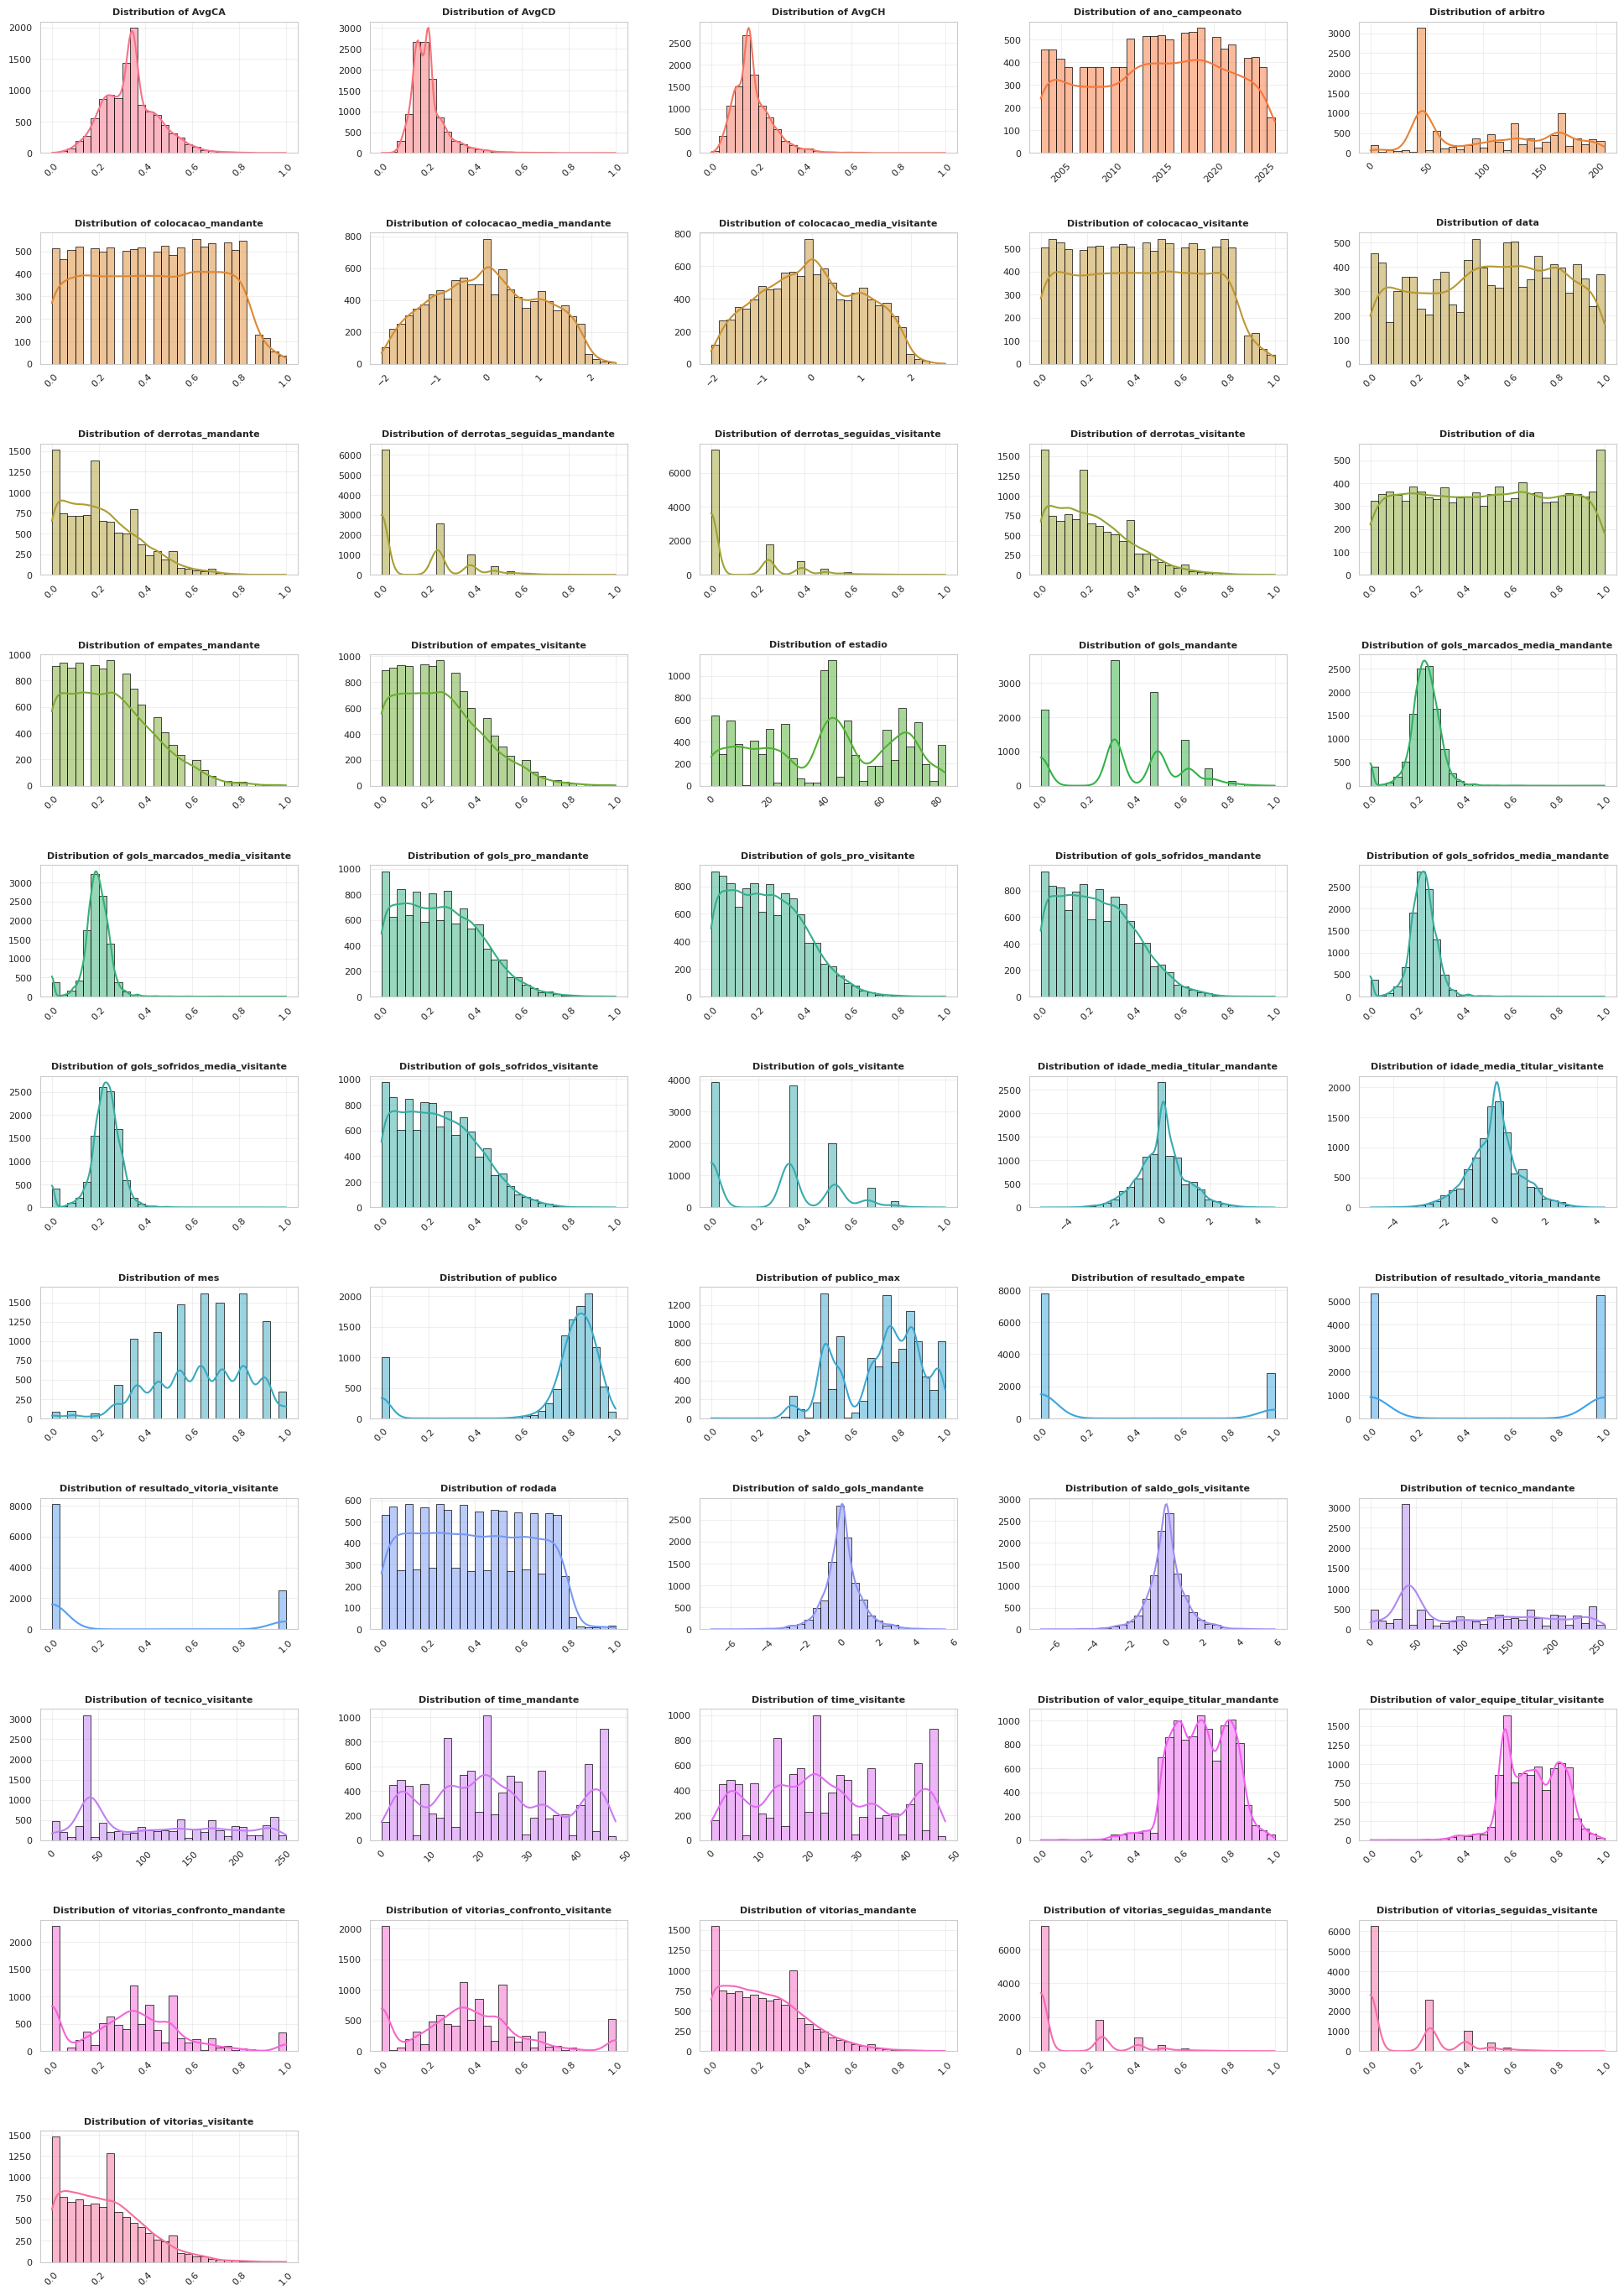

In [4]:
plot_distributions(dataset)

In [5]:
dataset.to_csv('dataset_scaled.csv', index=False)

dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 10624 entries, 0 to 10623
Data columns (total 51 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ano_campeonato                  10624 non-null  int64  
 1   data                            10624 non-null  float64
 2   rodada                          10624 non-null  float64
 3   estadio                         10624 non-null  int64  
 4   arbitro                         10624 non-null  int64  
 5   publico                         10624 non-null  float64
 6   publico_max                     10624 non-null  float64
 7   time_mandante                   10624 non-null  int64  
 8   time_visitante                  10624 non-null  int64  
 9   tecnico_mandante                10624 non-null  int64  
 10  tecnico_visitante               10624 non-null  int64  
 11  colocacao_mandante              10624 non-null  float64
 12  colocacao_visitante             10624 non-n